In [1]:
import os 
from pathlib import Path 
import sys 

In [2]:
# i want to add the parent directory to the sys.path so that i can import nnetflow 
Path(os.curdir).resolve().parent

sys.path.append(str(Path(os.curdir).resolve().parent))

✅ Graph saved as: simple_op.png
   (Open it with any image viewer or browser)
✅ Graph saved as: my_model_graph.png
   (Open it with any image viewer or browser)


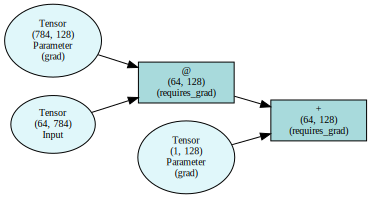

In [6]:
from nnetflow import Tensor, Linear
from nnetflow.layers import Conv2d
from nnetflow.visualize import draw_dot, visualize_model
from nnetflow.module import Module 
# 1. Single tensor operation graph
x = Tensor.randn(32, 10, requires_grad=True)
y = (x @ Tensor.randn(10, 5)).relu()
draw_dot(y, filename="simple_op")

# 2. Full model graph (recommended way)
model = Linear(784, 128)  # or any combination of layers
dummy = Tensor.randn(64, 784)
output = model(dummy)
visualize_model(output, filename="my_model_graph")   # or just draw_dot(output)

In [9]:
# a bigger model example 

class MyModel(Module):
    def __init__(self):
        super().__init__()
        self.conv1 = Conv2d(3, 16, kernel_size=3)
        self.conv2 = Conv2d(16, 32, kernel_size=3)
        self.fc2 = Linear(128, 10)
        self.fc1 = Linear(32 * 28 * 28, 128)   # after two convs without pooling

    def forward(self, x):
        x = self.conv1(x).relu()
        x = self.conv2(x).relu()
        x = x.view(x.shape[0], -1)  # flatten
        x = self.fc1(x).relu()
        return self.fc2(x) 


In [10]:
model = MyModel() 
dummy_input = Tensor.randn(64, 3, 32, 32) 
output = model(dummy_input) 

✅ Graph saved as: bigger_model.png
   (Open it with any image viewer or browser)


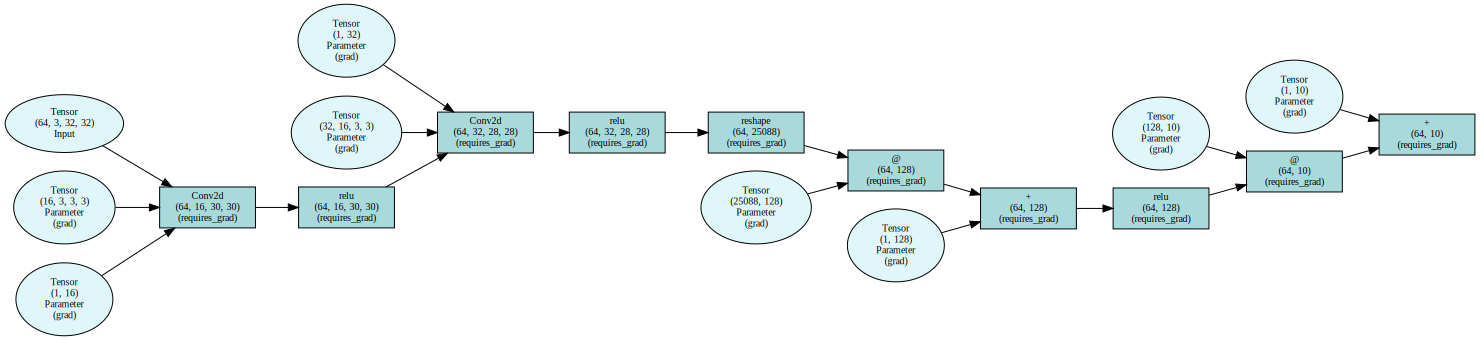

In [11]:
visualize_model(output,filename="bigger_model")